# NB09: 5가지 제약 레이어 점수화 — Constraint Layers (Step 2)

**목적**: H3 그리드 셀마다 5가지 독립적 제약 점수를 계산. Tableau에서 사용자가 On/Off 토글 시 실시간 필터링.

| Layer | Type | Score Logic |
|-------|------|-------------|
| 1. 공역 (Airspace) | Hard Filter | 0 = 비행금지, 1 = 가능 |
| 2. 장애물 (Obstacle) | Soft Filter | 반경 200m 내 >15층 건물 수에 반비례 |
| 3. 소음 (Noise) | Weight Filter | 저층 주거 밀집 → 낮은 점수 |
| 4. 지형 (Terrain) | Zone Filter | 경사도<5° → 1.0, 5~15° → 0.5, >15° → 0.0 |
| 5. 기상 (Weather) | Weight Filter | 평균 풍속에 반비례 |

**종합 점수**: `composite = ∏(active layers)` (곱셈식 → 하나라도 0이면 탈락)

**입력**: `processed/delivery_urgency_grid.gpkg`, 건물/경사도/공역/기상 데이터  
**출력**: `processed/constraint_layers.gpkg` (H3 grid + 5개 점수 컬럼)

In [10]:
import pandas as pd
import geopandas as gpd
import requests
from shapely.geometry import Point
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
import urllib3
import warnings
import numpy as np

warnings.filterwarnings("ignore")
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

BASE = Path("..").resolve()
RAW  = BASE / "00_data"
OUT  = BASE / "processed"

# 1. H3 배달 수요 그리드 로드 (NB04 출력)
demand_h3 = gpd.read_file(OUT / "delivery_demand_h3.gpkg")
print(f"H3 배달 수요 그리드: {len(demand_h3)} 셀")

# h3_index 컬럼 확인
if "h3_index" not in demand_h3.columns:
    # fallback: rename h3_09 if still present
    if "h3_09" in demand_h3.columns:
        demand_h3 = demand_h3.rename(columns={"h3_09": "h3_index"})
    else:
        raise KeyError("demand_h3 has no h3_index or h3_09 column")

# 2. 유동인구 집계 로드 (NB05 출력)
flow_pop = pd.read_parquet(OUT / "flow_pop_agg.parquet")
print(f"유동인구 집계: {len(flow_pop)} 동")

# 3. 크로스워크 + 경계 로드 (행정동 공간조인용)
crosswalk = pd.read_csv(OUT / "admin_code_crosswalk.csv")
crosswalk["CSV_ADMI_CD"] = crosswalk["CSV_ADMI_CD"].astype(str).str.split(".").str[0]
crosswalk["SHP_ADM_CD"] = crosswalk["SHP_ADM_CD"].astype(str).str.split(".").str[0]

dong_boundary = gpd.read_file(OUT / "seoul_boundary.gpkg", layer="dong")
dong_boundary["SHP_ADM_CD"] = dong_boundary["SHP_ADM_CD"].astype(str)

# 4. H3 셀 중심점을 행정동에 매핑
h3_centroids = demand_h3[["h3_index"]].copy()
h3_centroids["geometry"] = demand_h3.geometry.centroid

h3_centroids_gdf = gpd.GeoDataFrame(h3_centroids, geometry="geometry", crs=demand_h3.crs)

dong_for_join = dong_boundary[["SHP_ADM_CD", "ADM_NM", "GU_NM", "geometry"]].copy()
h3_with_dong = gpd.sjoin(h3_centroids_gdf, dong_for_join, how="left", predicate="within")
h3_with_dong = h3_with_dong[["h3_index", "SHP_ADM_CD", "ADM_NM", "GU_NM"]].drop_duplicates("h3_index")

# 5. 크로스워크로 CSV_ADMI_CD 연결
h3_with_dong = h3_with_dong.merge(
    crosswalk[["SHP_ADM_CD", "CSV_ADMI_CD"]],
    on="SHP_ADM_CD",
    how="left",
)
h3_with_dong["CSV_ADMI_CD"] = h3_with_dong["CSV_ADMI_CD"].astype(str).str.split(".").str[0]

# 6. 유동인구 지수 연결
flow_pop["CSV_ADMI_CD"] = flow_pop["CSV_ADMI_CD"].astype(str)
h3_flow = h3_with_dong.merge(
    flow_pop[["CSV_ADMI_CD", "flow_pop_index"]],
    on="CSV_ADMI_CD",
    how="left",
)

# 7. 수요 지수 + 유동인구 지수를 H3 원본 GeoDataFrame에 병합
gdf = demand_h3.merge(h3_flow, on="h3_index", how="left")

# 8. 인덱스 컬럼 표준화 (0~1로 정규화)
if "h3_demand_index" in gdf.columns:
    gdf["delivery_demand_index"] = gdf["h3_demand_index"] / 100.0
else:
    mn, mx = gdf["h3_demand_score"].min(), gdf["h3_demand_score"].max()
    gdf["delivery_demand_index"] = (gdf["h3_demand_score"] - mn) / (mx - mn + 1e-9)

gdf["flow_pop_index"] = gdf["flow_pop_index"].fillna(0.0)

# 9. Urgency 산출
gdf["urgency"] = 0.5 * gdf["delivery_demand_index"] + 0.5 * gdf["flow_pop_index"]

print(f"\n병합 완료: {len(gdf)} H3 셀")
print(f"urgency 통계: mean={gdf['urgency'].mean():.3f}, max={gdf['urgency'].max():.3f}")
print(f"ADM_NM 매핑 성공률: {gdf['ADM_NM'].notna().mean()*100:.1f}%")


H3 배달 수요 그리드: 9635 셀
유동인구 집계: 408 동

병합 완료: 9635 H3 셀
urgency 통계: mean=0.118, max=0.657
ADM_NM 매핑 성공률: 98.8%


## Layer 1: 공역 제약 (Airspace) — Hard Filter

서울공항(성남 비행장) 관제권 P-73/R-75 기반.  
> 데이터 미확보 시 관제권 중심 좌표 + 반경으로 근사 생성

In [11]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point

# OUT 경로는 기존 코드에 정의되어 있다고 가정
airspace_path = OUT / "airspace_constraint.gpkg"

if airspace_path.exists():
    airspace = gpd.read_file(airspace_path)
    print(f"공역 제약 데이터 로드 완료: {len(airspace)} zones")
else:
    print("⚠ 공역 데이터 미확보 — 핵심 관제권 및 비행금지구역(D-3554 포함)을 원형으로 근사 생성합니다.")

    # 1. 주요 Hard Constraints 중심점 및 반경 세팅
    constraints_data = {
        "name": [
            "서울공항(K-16) 관제권", 
            "김포국제공항 관제권", 
            "P-73 용산 비행금지구역"
        ],
        "lon": [
            127.1141, 
            126.7906, 
            126.9750, 
        ],
        "lat": [
            37.4449, 
            37.5586, 
            37.5350, 
        ],
        "radius_m": [
            9300, 
            9300, 
            3700, 
        ] 
    }
    
    # Point 객체 생성
    geometry = [Point(lon, lat) for lon, lat in zip(constraints_data["lon"], constraints_data["lat"])]
    
    constraint_pts = gpd.GeoDataFrame(
        constraints_data, 
        geometry=geometry, 
        crs="EPSG:4326"
    )

    # 2. EPSG:5179(미터 단위)로 변환 후 버퍼 적용
    constraint_5179 = constraint_pts.to_crs(epsg=5179)
    constraint_5179["geometry"] = constraint_5179.geometry.buffer(constraint_5179["radius_m"])

    # 다시 EPSG:4326으로 변환하여 최종 폴리곤 레이어 생성
    airspace = constraint_5179.to_crs(epsg=4326)
    
    for i, row in constraint_pts.iterrows():
        print(f"  - {row['name']} 근사 원: 중심 ({row['lat']:.4f}, {row['lon']:.4f}), 반경 {row['radius_m']/1000}km")

# ==========================================
# 각 H3 셀이 관제권/비행금지구역 내부에 있는지 체크 (Hard Filter 적용)
# ==========================================

# H3 셀 중심점 생성 (gdf가 메모리에 있다고 가정)
hex_centers = gpd.GeoDataFrame(
    gdf[["h3_index"]],
    geometry=gdf["geometry"].centroid,
    crs="EPSG:4326",
)

# sjoin 수행: H3 중심점이 airspace 폴리곤 내부에(within) 있는지 확인
in_airspace = gpd.sjoin(hex_centers, airspace[["geometry"]], predicate="within", how="left")

# 핵심 방어 로직: 제약구역에 하나라도 포함된(notna) 고유한 h3_index만 추출
restricted_h3_indices = in_airspace[in_airspace["index_right"].notna()]["h3_index"].unique()

# 필터링 점수 부여 (제약구역 내부면 0.0, 아니면 1.0)
gdf["score_airspace"] = np.where(gdf["h3_index"].isin(restricted_h3_indices), 0.0, 1.0)

n_restricted = (gdf["score_airspace"] == 0).sum()
print(f"\n🚫 공역 제한(Hard Filter) 셀: {n_restricted} / {len(gdf)} ({n_restricted/len(gdf)*100:.1f}%)")

⚠ 공역 데이터 미확보 — 핵심 관제권 및 비행금지구역(D-3554 포함)을 원형으로 근사 생성합니다.
  - 서울공항(K-16) 관제권 근사 원: 중심 (37.4449, 127.1141), 반경 9.3km
  - 김포국제공항 관제권 근사 원: 중심 (37.5586, 126.7906), 반경 9.3km
  - P-73 용산 비행금지구역 근사 원: 중심 (37.5350, 126.9750), 반경 3.7km

🚫 공역 제한(Hard Filter) 셀: 3259 / 9635 (33.8%)


## Layer 2: 장애물 (Obstacle) — Soft Filter

반경 200m 내 고층 건물(>15층) 밀집도. 건물 층수 데이터가 없으면 대형 건물 면적(>1000m²)으로 대체.

In [12]:
bldg_path = OUT / "seoul_buildings.gpkg"

if bldg_path.exists():
    bldg = gpd.read_file(bldg_path, layer="buildings_5179")
    
    # 층수 데이터 있으면 >15층, 없으면 대형 건물(>1000m²)로 대체
    # NB02에서 생성한 is_highrise(>30m) 또는 floors(>15층) 변수 활용
    if "is_highrise" in bldg.columns:
        tall_bldg = bldg[bldg["is_highrise"]].copy()
        print(f"고층 건물 (is_highrise): {len(tall_bldg)}동")
    elif "floors" in bldg.columns and bldg["floors"].notna().any():
        tall_bldg = bldg[bldg["floors"] > 15].copy()
        print(f"고층 건물 (>15층): {len(tall_bldg)}동")
    else:
        bldg["area_m2"] = bldg.geometry.area
        tall_bldg = bldg[bldg["area_m2"] > 1000].copy()
        print(f"대형 건물 (>1000m², 고층 대용): {len(tall_bldg)}동")
    
    # H3 셀 중심을 EPSG:5179로 변환 후 200m 버퍼 내 고층 건물 수 카운트
    # gdf에 lon, lat 컬럼이 없을 수 있으므로 geometry의 centroid를 직접 계산 후 변환
    hex_5179 = gdf[["h3_index", "geometry"]].copy()
    # 이미 4326 좌표계라면 5179로 변환 후 중심점 추출
    hex_5179["geometry"] = hex_5179.to_crs(epsg=5179).geometry.centroid
    hex_5179["geometry"] = hex_5179.buffer(200)

    tall_bldg_5179 = tall_bldg.to_crs(epsg=5179)
    
    joined = gpd.sjoin(hex_5179, tall_bldg_5179[["geometry"]], predicate="intersects", how="left")
    obstacle_count = joined.groupby("h3_index")["index_right"].count().reset_index()
    obstacle_count.columns = ["h3_index", "tall_bldg_count"]
    
    if "tall_bldg_count" in gdf.columns:
        gdf = gdf.drop(columns=["tall_bldg_count"])
    gdf = gdf.merge(obstacle_count, on="h3_index", how="left")
    gdf["tall_bldg_count"] = gdf["tall_bldg_count"].fillna(0)
    
    # 점수화: 0~max → 1.0~0.3 (완전 차단은 안 함, soft filter)
    max_count = gdf["tall_bldg_count"].quantile(0.95)  # 상위 5% 기준
    max_count = max(max_count, 1)
    gdf["score_obstacle"] = 1.0 - 0.7 * np.minimum(gdf["tall_bldg_count"] / max_count, 1.0)
else:
    print("⚠ 건물 데이터 미확보 — score_obstacle = 1.0 (제약 없음)")
    gdf["score_obstacle"] = 1.0
    gdf["tall_bldg_count"] = 0

print(f"장애물 점수 분포: min={gdf['score_obstacle'].min():.2f}, max={gdf['score_obstacle'].max():.2f}")

고층 건물 (is_highrise): 19513동
장애물 점수 분포: min=0.30, max=1.00


## Layer 3: 소음 (Noise) — Weight Filter

저층 주거 밀집지 = 소음 민원 예상. 건물 밀도와 주거 비율로 추정.

In [13]:
# Layer 3: 소음 민감도 — 소음진동 민원 현황 (2024, 구별)
# 구별 소음진동 민원 건수가 많을수록 주민 소음 민감도가 높음 → 드론 운항 소음 제약
# score_noise = 1 - 0.4 * (구별 민원 수 / 최대 민원 수)  [0.60 ~ 1.00]
NOISE_CSV = RAW / "소음진동민원+현황.csv"

if NOISE_CSV.exists() and "GU_NM" in gdf.columns:
    # 헤더 2줄 스킵 (rows 0-1은 다중 헤더, row 2부터 실제 데이터)
    noise_raw = pd.read_csv(NOISE_CSV, encoding="utf-8-sig", header=None, skiprows=2)
    noise_raw.columns = ["level1", "gu_nm", "env_total", "noise_total", "factory", "traffic", "daily"]

    # '소계' 행(서울 전체 합계) 제외 → 구 단위 행만 추출
    noise_gu = noise_raw[noise_raw["gu_nm"] != "소계"].copy()
    noise_gu["noise_total"] = (
        pd.to_numeric(noise_gu["noise_total"].replace("-", "0"), errors="coerce")
        .fillna(0).astype(int)
    )
    noise_gu = noise_gu[["gu_nm", "noise_total"]].reset_index(drop=True)

    # 정규화 (0~1) 후 최대 40% 감점
    max_val = noise_gu["noise_total"].max()
    noise_gu["noise_norm"] = noise_gu["noise_total"] / max(max_val, 1)
    noise_gu["score_noise"] = (1.0 - 0.4 * noise_gu["noise_norm"]).round(4)

    # 기존 noise 컬럼 제거 후 병합
    for col in ["noise_total", "score_noise", "gu_nm"]:
        if col in gdf.columns:
            gdf = gdf.drop(columns=[col])
    gdf = gdf.merge(
        noise_gu[["gu_nm", "noise_total", "score_noise"]],
        left_on="GU_NM", right_on="gu_nm", how="left",
    )
    gdf["score_noise"] = gdf["score_noise"].fillna(1.0)
    gdf["noise_total"] = gdf["noise_total"].fillna(0)
    if "gu_nm" in gdf.columns:
        gdf = gdf.drop(columns=["gu_nm"])

    print("=== 구별 소음진동 민원 → score_noise ===")
    print(
        noise_gu[["gu_nm", "noise_total", "score_noise"]]
        .sort_values("noise_total", ascending=False)
        .to_string(index=False)
    )
else:
    gdf["score_noise"] = 1.0
    gdf["noise_total"] = 0
    if not NOISE_CSV.exists():
        print(f"[경고] 소음 민원 CSV 없음: {NOISE_CSV}")
    else:
        print("[경고] GU_NM 컬럼 없음 — 소음 점수 기본값 1.0 사용")

print(f"\n소음 점수 분포: min={gdf['score_noise'].min():.3f}, max={gdf['score_noise'].max():.3f}")

=== 구별 소음진동 민원 → score_noise ===
  gu_nm  noise_total  score_noise
    강남구         9494       0.6000
    서초구         4717       0.8013
   영등포구         4268       0.8202
   동대문구         3447       0.8548
    마포구         2756       0.8839
    강서구         2685       0.8869
    용산구         2673       0.8874
    성북구         2478       0.8956
    성동구         2477       0.8956
    송파구         2430       0.8976
    강동구         2361       0.9005
   서대문구         2109       0.9111
    종로구         2057       0.9133
    관악구         1842       0.9224
    동작구         1619       0.9318
    중랑구         1523       0.9358
    광진구         1329       0.9440
    강북구         1311       0.9448
    금천구         1237       0.9479
    은평구         1234       0.9480
     중구         1180       0.9503
    구로구         1114       0.9531
    양천구         1104       0.9535
    노원구         1078       0.9546
    도봉구          740       0.9688
자치구별(2)            0       1.0000

소음 점수 분포: min=0.600, max=1.000


## Layer 4: 지형/로봇 제약 (Terrain) — 프로젝트 핵심 레이어

경사도 기반 로봇 배송 가능 구역 분류:
- Green Zone (< 5°): 로봇 배송 가능 → score = 1.0
- Yellow Zone (5~15°): 로봇 제약 → score = 0.5
- Red Zone (> 15°): 로봇 불가 → score = 0.0

In [14]:
slope_path = RAW / "slope" / "seoul_slope.tif"

if slope_path.exists():
    import rasterio
    import numpy as np
    
    with rasterio.open(slope_path) as src:
        slope_data = src.read(1)
        slope_transform = src.transform
        raster_crs = src.crs  # 🌟 래스터 파일의 좌표계 읽어오기
    
    # 🌟 1. H3 중심점 Geometry 생성 및 래스터 좌표계로 변환
    # (lon, lat 컬럼을 이용해 먼저 4326 좌표계로 Point 생성 후 변환)
    pts = gdf["geometry"].centroid
    pts_projected = pts.to_crs(raster_crs)
    
    # 🌟 2. 변환된 좌표(m 단위)로 경사도 추출
    slopes = []
    for geom in pts_projected:
        col_idx, row_idx = ~slope_transform * (geom.x, geom.y)
        col_idx, row_idx = int(col_idx), int(row_idx)
        
        if 0 <= row_idx < slope_data.shape[0] and 0 <= col_idx < slope_data.shape[1]:
            # 래스터의 NoData 값(보통 음수나 매우 큰 수) 처리
            val = slope_data[row_idx, col_idx]
            if val < 0 or val > 100:  # 일반적인 경사도 범위를 벗어나면 결측치 처리
                slopes.append(np.nan)
            else:
                slopes.append(val)
        else:
            slopes.append(np.nan)
    
    gdf["avg_slope"] = slopes
    
    # NaN 값은 0으로 임시 채우거나 평균값 등으로 대체 (선택 사항)
    gdf["avg_slope"] = gdf["avg_slope"].fillna(0)
    
    # 점수화
    gdf["score_terrain"] = np.where(
        gdf["avg_slope"] < 5, 1.0,
        np.where(gdf["avg_slope"] < 15, 0.5, 0.0)
    )
    
    # Zone 분류 (Tableau 필터용)
    gdf["terrain_zone"] = np.where(
        gdf["avg_slope"] < 5, "Green",
        np.where(gdf["avg_slope"] < 15, "Yellow", "Red")
    )
    
    print(f"경사도 통계: 평균 {gdf['avg_slope'].mean():.1f}°, 최대 {gdf['avg_slope'].max():.1f}°")
    print(f"\nZone 분포:")
    print(gdf["terrain_zone"].value_counts())
else:
    print("⚠ 경사도 데이터 미확보 — NB03 실행 후 재실행")
    print("  score_terrain = 1.0 (제약 없음으로 임시 설정)")
    gdf["score_terrain"] = 1.0
    gdf["avg_slope"] = np.nan
    gdf["terrain_zone"] = "Unknown"

경사도 통계: 평균 4.5°, 최대 75.1°

Zone 분포:
terrain_zone
Green     6968
Yellow    2291
Red        376
Name: count, dtype: int64


## Layer 5: 기상/풍속 (Weather) — Weight Filter

> 데이터 미확보 시 기본값 0.8 적용 (대부분 지역에서 약한 제약)

In [15]:
# Layer 5: 기상/풍속 — 드론 운항 가용성 (구별 월별 시간대별 실측, 2025)
# 배달 시간대(08-21시) 기준 연평균 드론 운항 불가/제한 비율로 가중치 산출
# score_weather: 최악 구 → SCORE_MIN, 최선 구 → 1.0  (min-max 정규화)
WEATHER_CSV = RAW / "seoul_gu_monthly_hourly_weather_summary_2025.csv"
DELIVERY_HOURS = range(8, 22)  # 08:00-21:00
SCORE_MIN = 0.70  # 가장 기상이 나쁜 구에 부여할 최저 점수 (0~1)

if WEATHER_CSV.exists() and "GU_NM" in gdf.columns:
    wx = pd.read_csv(WEATHER_CSV, encoding="utf-8-sig")

    # 배달 시간대 필터
    wx_day = wx[wx["hour"].isin(DELIVERY_HOURS)].copy()

    # 구별 연간 평균 집계
    wx_gu = (
        wx_day.groupby("gu_name")
        .agg(
            avg_available_pct=("available_ratio_percent", "mean"),
            avg_unavail_pct=("unavailable_ratio_percent", "mean"),
            avg_restricted_pct=("restricted_ratio_percent", "mean"),
            avg_wind_ms=("avg_wind_speed_ms", "mean"),
            p90_wind_ms=("p90_wind_speed_ms", "mean"),
        )
        .round(4)
        .reset_index()
    )

    # 기상 위험 원점수 = 불가비율 + 0.5 × 제한비율
    wx_gu["weather_risk"] = (
        wx_gu["avg_unavail_pct"] / 100
        + 0.5 * wx_gu["avg_restricted_pct"] / 100
    ).round(4)
    raw_score = 1.0 - wx_gu["weather_risk"]

    # Min-max 정규화: 실제 구별 차이를 [SCORE_MIN, 1.0] 범위로 확장
    r_min, r_max = raw_score.min(), raw_score.max()
    if r_max > r_min:
        wx_gu["score_weather"] = (
            SCORE_MIN + (raw_score - r_min) / (r_max - r_min) * (1.0 - SCORE_MIN)
        ).round(4)
    else:
        wx_gu["score_weather"] = raw_score.round(4)

    # 기존 컬럼 제거 후 병합
    drop_cols = ["avg_available_pct", "avg_unavail_pct", "avg_wind_ms", "score_weather", "gu_name"]
    gdf = gdf.drop(columns=[c for c in drop_cols if c in gdf.columns])
    gdf = gdf.merge(
        wx_gu[["gu_name", "avg_available_pct", "avg_unavail_pct", "avg_wind_ms", "score_weather"]],
        left_on="GU_NM", right_on="gu_name", how="left",
    )
    gdf["score_weather"] = gdf["score_weather"].fillna(SCORE_MIN + (1.0 - SCORE_MIN) * 0.5)
    gdf["avg_available_pct"] = gdf["avg_available_pct"].fillna(0)
    gdf["avg_wind_ms"] = gdf["avg_wind_ms"].fillna(0)
    if "gu_name" in gdf.columns:
        gdf = gdf.drop(columns=["gu_name"])

    print(f"=== 구별 기상 운항 가용성 → score_weather (SCORE_MIN={SCORE_MIN}) ===")
    print("[배달 시간대 08-21시 기준, 2025 연간 평균 / min-max 정규화]")
    display_cols = ["gu_name", "avg_available_pct", "avg_unavail_pct", "avg_restricted_pct", "avg_wind_ms", "score_weather"]
    print(
        wx_gu[display_cols]
        .sort_values("score_weather")
        .to_string(index=False)
    )
else:
    gdf["score_weather"] = SCORE_MIN + (1.0 - SCORE_MIN) * 0.5
    gdf["avg_available_pct"] = 0
    gdf["avg_wind_ms"] = 0
    if not WEATHER_CSV.exists():
        print(f"[경고] 기상 데이터 없음: {WEATHER_CSV}")
    else:
        print("[경고] GU_NM 컬럼 없음 — 기상 점수 기본값 사용")

print(f"\n기상 점수 분포: min={gdf['score_weather'].min():.3f}, max={gdf['score_weather'].max():.3f}")


=== 구별 기상 운항 가용성 → score_weather (SCORE_MIN=0.7) ===
[배달 시간대 08-21시 기준, 2025 연간 평균 / min-max 정규화]
gu_name  avg_available_pct  avg_unavail_pct  avg_restricted_pct  avg_wind_ms  score_weather
    강북구            92.7230           4.8751              2.4024       1.1819         0.7000
    종로구            91.7330           3.7180              4.5498       2.4059         0.7156
     중구            91.7330           3.7180              4.5498       2.4059         0.7156
    마포구            91.7857           3.3473              4.8679       2.9042         0.7520
    도봉구            93.1166           4.4635              2.4205       1.3000         0.7711
    성북구            93.1987           4.1607              2.6410       2.0389         0.8040
    관악구            93.2046           4.1077              2.6879       1.8169         0.8092
    중랑구            93.2869           4.1523              2.5612       2.2541         0.8127
    강동구            93.5593           4.0783              2.3629       1.68

## 6. 종합 점수 (Composite Score)

`composite = score_airspace × score_obstacle × score_noise × score_terrain × score_weather`

곱셈식이므로 하나라도 0이면 해당 셀은 자동 탈락.  
Tableau에서는 Parameter 토글로 비활성 레이어를 1.0으로 대체하여 동적 재계산.

In [16]:
# 종합 점수 = 5개 레이어 곱
score_cols = ["score_airspace", "score_obstacle", "score_noise", "score_terrain", "score_weather"]
gdf["composite_score"] = gdf[score_cols].prod(axis=1)

# 결과 요약
print("=== 종합 점수 통계 ===")
print(gdf["composite_score"].describe())

print(f"\n탈락 셀 (composite=0): {(gdf['composite_score']==0).sum()}/{len(gdf)} "
      f"({(gdf['composite_score']==0).mean()*100:.1f}%)")
print(f"완전 통과 셀 (composite≥0.8): {(gdf['composite_score']>=0.8).sum()} "
      f"({(gdf['composite_score']>=0.8).mean()*100:.1f}%)")

# 각 레이어별 평균
print("\n=== 레이어별 평균 점수 ===")
for col in score_cols:
    layer_name = col.replace("score_", "")
    zero_pct = (gdf[col] == 0).mean() * 100
    print(f"  {layer_name:12s}: mean={gdf[col].mean():.3f}, zero={zero_pct:.1f}%")

=== 종합 점수 통계 ===
count    9635.000000
mean        0.339300
std         0.305847
min         0.000000
25%         0.000000
50%         0.338109
75%         0.633771
max         0.896517
Name: composite_score, dtype: float64

탈락 셀 (composite=0): 3552/9635 (36.9%)
완전 통과 셀 (composite≥0.8): 600 (6.2%)

=== 레이어별 평균 점수 ===
  airspace    : mean=0.662, zero=33.8%
  obstacle    : mean=0.827, zero=0.0%
  noise       : mean=0.888, zero=0.0%
  terrain     : mean=0.842, zero=3.9%
  weather     : mean=0.858, zero=0.0%


## 7. 시각화: 5-Layer 비교 + 종합 점수 맵

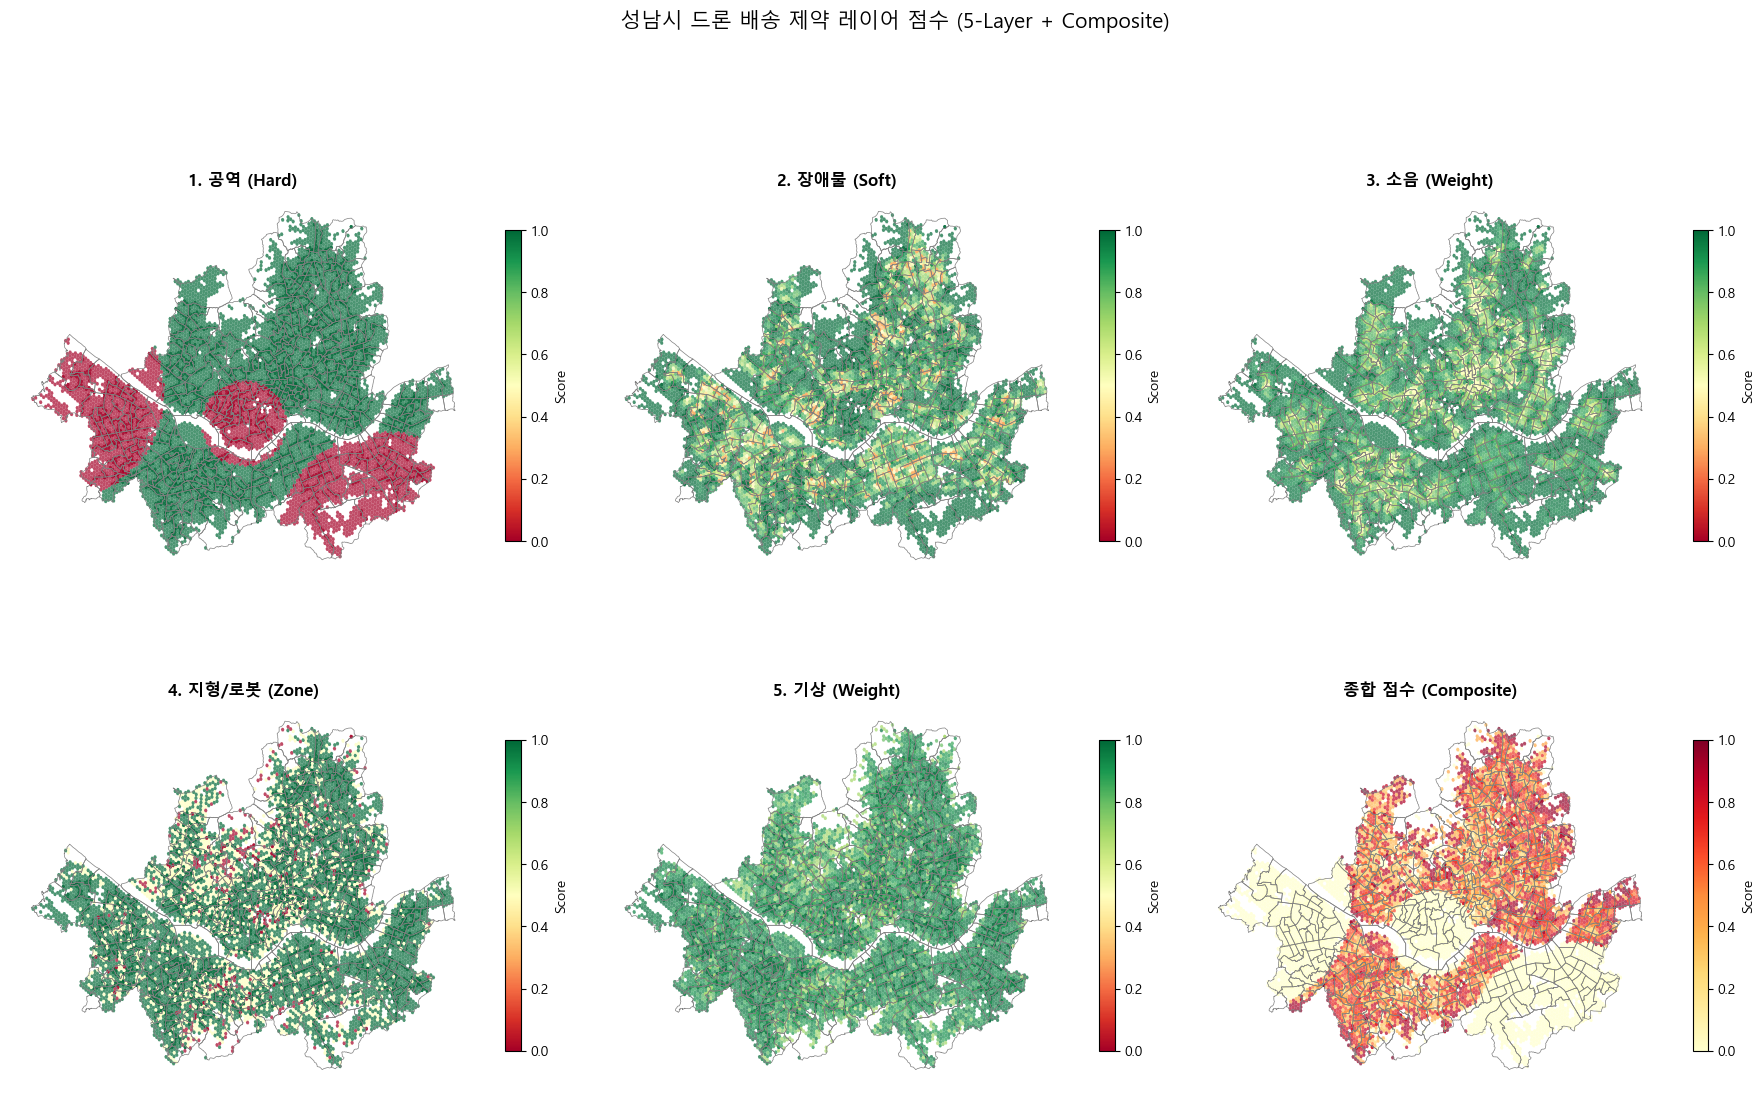

In [31]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

seongnam = gpd.read_file(OUT / "seoul_boundary.gpkg", layer="dong")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

layers = [
    ("score_airspace", "1. 공역 (Hard)", "RdYlGn"),
    ("score_obstacle", "2. 장애물 (Soft)", "RdYlGn"),
    ("score_noise", "3. 소음 (Weight)", "RdYlGn"),
    ("score_terrain", "4. 지형/로봇 (Zone)", "RdYlGn"),
    ("score_weather", "5. 기상 (Weight)", "RdYlGn"),
    ("composite_score", "종합 점수 (Composite)", "YlOrRd"),
]

for ax, (col, title, cmap) in zip(axes.flat, layers):
    seongnam.boundary.plot(ax=ax, color="gray", linewidth=0.5)
    gdf.plot(
        ax=ax, column=col, cmap=cmap, legend=True,
        alpha=0.7, edgecolor="none", vmin=0, vmax=1,
        legend_kwds={"shrink": 0.5, "label": "Score"},
    )
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_axis_off()

plt.suptitle("성남시 드론 배송 제약 레이어 점수 (5-Layer + Composite)", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 8. 저장

In [17]:
gdf

,CSV_ADMI_CD_x,h3_index,h3_demand_score,h3_demand_index,geometry,SHP_ADM_CD,ADM_NM,GU_NM,CSV_ADMI_CD_y,flow_pop_index,...,noise_total,score_noise,avg_slope,score_terrain,terrain_zone,avg_available_pct,avg_unavail_pct,avg_wind_ms,score_weather,composite_score
0,11110515,8930e1d8c83ffff,586.580549,1.517291,"POLYGON ((126.97618 37.57527, 126.97543 37.576...",11010530,사직동,종로구,11110530,0.205734,...,2057.0,0.9133,4.727566,1.0,Green,91.7330,3.7180,2.4059,0.7156,0.413920
1,11110515,8930e1d8c87ffff,31.083925,0.080404,"POLYGON ((126.97889 37.57636, 126.97814 37.577...",11010720,청운효자동,종로구,11110515,0.105479,...,2057.0,0.9133,0.796624,1.0,Green,91.7330,3.7180,2.4059,0.7156,0.653557
2,11110515,8930e1d8c93ffff,55.781012,0.144287,"POLYGON ((126.9737 37.577, 126.97295 37.57852,...",11010530,사직동,종로구,11110530,0.205734,...,2057.0,0.9133,5.990323,0.5,Yellow,91.7330,3.7180,2.4059,0.7156,0.304993
3,11110515,8930e1d8c97ffff,12.477072,0.032274,"POLYGON ((126.97641 37.57809, 126.97566 37.579...",11010720,청운효자동,종로구,11110515,0.105479,...,2057.0,0.9133,2.422407,1.0,Green,91.7330,3.7180,2.4059,0.7156,0.653557
4,11110515,8930e1d8cb3ffff,194.729319,0.503701,"POLYGON ((126.9816 37.57745, 126.98085 37.5789...",11010540,삼청동,종로구,11110540,0.025919,...,2057.0,0.9133,3.770869,1.0,Green,91.7330,3.7180,2.4059,0.7156,0.653557
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9630,11740700,8930e1cf56bffff,1146.088810,2.964555,"POLYGON ((127.14814 37.52949, 127.14739 37.531...",11250710,둔촌2동,강동구,11740700,0.177154,...,2361.0,0.9005,0.843181,1.0,Green,93.5593,4.0783,1.6814,0.8422,0.707841
9631,11740700,8930e1cf56fffff,2202.856225,5.698065,"POLYGON ((127.15086 37.53058, 127.15011 37.532...",11250710,둔촌2동,강동구,11740700,0.177154,...,2361.0,0.9005,0.884915,1.0,Green,93.5593,4.0783,1.6814,0.8422,0.745761
9632,11740700,8930e1cf573ffff,1720.417911,4.450156,"POLYGON ((127.1459 37.53406, 127.14515 37.5355...",11250710,둔촌2동,강동구,11740700,0.177154,...,2361.0,0.9005,0.265387,1.0,Green,93.5593,4.0783,1.6814,0.8422,0.530881
9633,11740700,8930e1cf577ffff,2114.632660,5.469860,"POLYGON ((127.14862 37.53515, 127.14787 37.536...",11250710,둔촌2동,강동구,11740700,0.177154,...,2361.0,0.9005,0.713018,1.0,Green,93.5593,4.0783,1.6814,0.8422,0.252800


In [18]:
# 저장할 컬럼 정리
keep_cols = [
    "h3_index", "centroid", "geometry",
    "CSV_ADMI_CD", "ADM_NM", "GU_NM",
    "delivery_demand_index", "flow_pop_index", "urgency",
    "score_airspace", "score_obstacle", "score_noise",
    "score_terrain", "score_weather", "composite_score",
    "tall_bldg_count", "noise_total",
    "avg_slope", "terrain_zone",
    "avg_available_pct", "avg_wind_ms",
]
# 존재하는 컬럼만 선택
keep_cols = [c for c in keep_cols if c in gdf.columns]
gdf_out = gdf[keep_cols].copy()

# GeoPackage 저장
gdf_out.to_file(OUT / "constraint_layers.gpkg", driver="GPKG")
print(f"저장 완료: {OUT / 'constraint_layers.gpkg'}")
print(f"  셀 수: {len(gdf_out)}")
print(f"  컬럼: {gdf_out.columns.tolist()}")

# Tableau용 CSV도 함께 저장 (geometry 제외, lat/lon으로 대체)
csv_out = gdf_out.drop(columns="geometry")
csv_out.to_csv(OUT / "constraint_layers.csv", index=False, encoding="utf-8-sig")
print(f"  CSV: {OUT / 'constraint_layers.csv'}")


저장 완료: C:\Users\jimin\Desktop\1_BITAmin_16기\skybase-seoul\skybase-seoul-v3\processed\constraint_layers.gpkg
  셀 수: 9635
  컬럼: ['h3_index', 'geometry', 'ADM_NM', 'GU_NM', 'delivery_demand_index', 'flow_pop_index', 'urgency', 'score_airspace', 'score_obstacle', 'score_noise', 'score_terrain', 'score_weather', 'composite_score', 'tall_bldg_count', 'noise_total', 'avg_slope', 'terrain_zone', 'avg_available_pct', 'avg_wind_ms']
  CSV: C:\Users\jimin\Desktop\1_BITAmin_16기\skybase-seoul\skybase-seoul-v3\processed\constraint_layers.csv
